# (26) analyze: vH32 + T16 + [256, 8, 8], 3

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>

Analyze this model.

This means:

- ```K = 256```
- ```M = 8```
- ```S = 3```

And:

- ```T_train = 16```

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Load model

In [3]:
a = 'poisson_vH32-wht_t-16_b-8_k-256_m-8_s-3_<ngd|lin>'
b = 'b100-ep400-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:SpaceBroadcast_(2025_06_25,12:32)'
tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

400

### sanity check

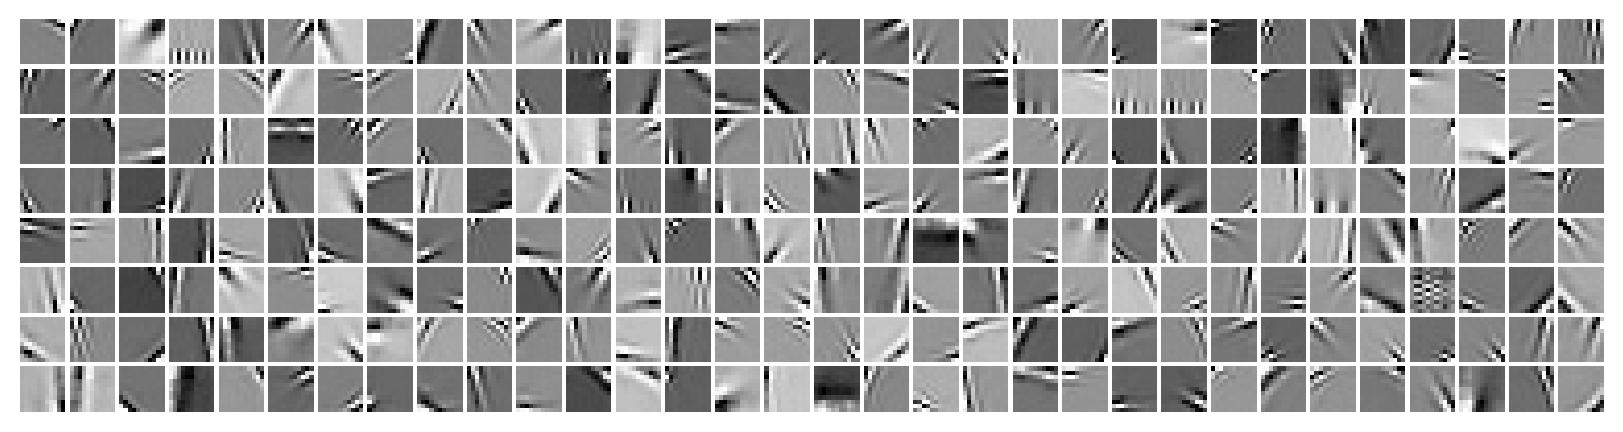

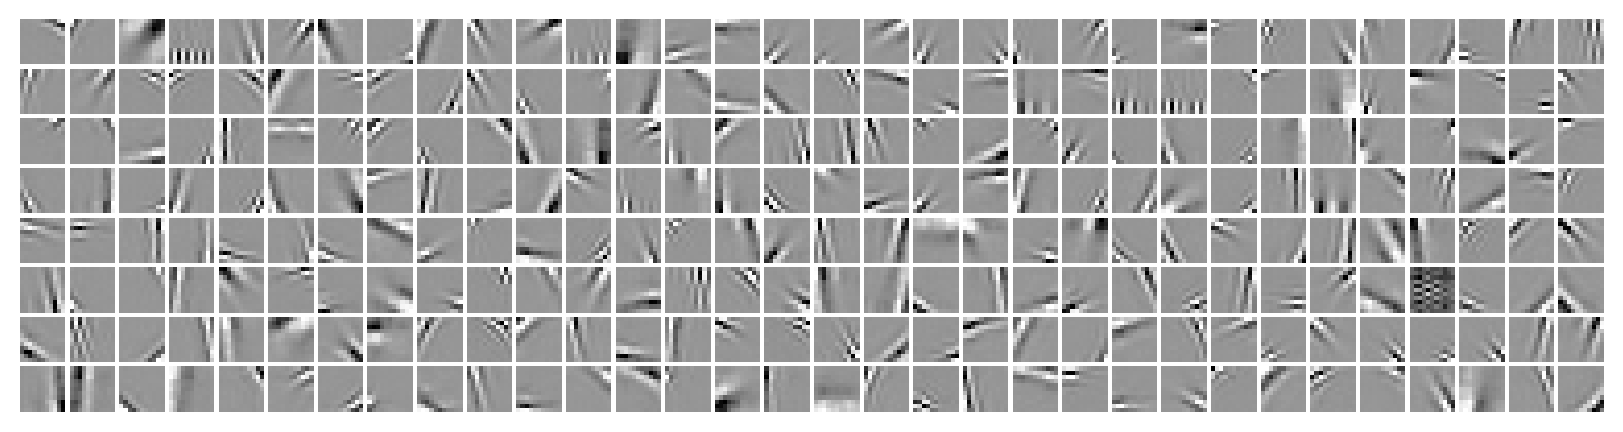

In [121]:
tr.model.show();
tr.model.show(method='abs-max');

In [123]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

MemoryError: Unable to allocate 12.5 TiB for an array with shape (500, 1000, 256, 164, 164) and data type float32

## Sparsity analysis

In [4]:
output = tr.xtract_ftr(data_batch_sz=2000)
list(output)

100%|███████████████████████████████████| 6/6 [01:20<00:00, 13.49s/it]


['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'times']

In [7]:
z = output['samples'][:, -1]
z.shape

(11303, 256, 8, 8)

In [9]:
life, pop, portions = sparse_score(flatten_np(z, start_dim=1, end_dim=-1), cutoff=0.01)

In [22]:
life.mean(), pop.mean(), portions

(0.97731614, 0.9782089, {'0': 96.1, '1': 1.4, '2': 0.8, '3+': 1.6})

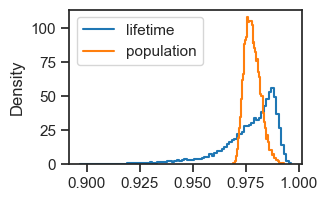

In [20]:
histplot(life, label='lifetime', stat='density')
histplot(pop, label='population', stat='density')
plt.legend()
plt.show()

## Load Kyoto image

In [4]:
root = 'Datasets/Kyoto/processed'
root = add_home(root)

os.listdir(root)

['kyoto_bnw.npy', 'kyoto_color.npy']

In [5]:
bw = np.load(pjoin(root, 'kyoto_bnw.npy'))
bw.shape

(62, 500, 500)

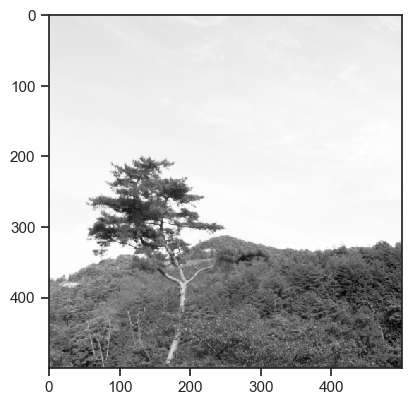

In [6]:
img_i = 58

fig, ax = create_figure(1, 1, (4, 4))
ax.imshow(bw[img_i], cmap='Greys_r')
plt.show()

In [7]:
print({k: v for k, v in vars(tr.model.cfg).items() if 'latent' in k or 'input' in k})

{'latent_channels': 256, 'latent_pixels': 8, 'latent_stride': 3, 'input_sz': (1, 32, 32), 'latent_sz': (256, 8, 8)}

In [8]:
print(tr.model.layer.dec)

ConvDictionary(in_channels=256, out_channels=1, kernel_size=11, stride=3)

In [9]:
from base.helper import conv_arithmetic

df = conv_arithmetic(
    input_size=None,
    output_size=500,
    kernel_size=11,
    stride=3,
    padding=0,
    deconv=True,
)
df

,mode,computed,parameter,value
0,deconv,True,input_size,164
1,deconv,False,output_size,500
2,deconv,False,kernel_size,11
3,deconv,False,stride,3
4,deconv,False,padding,0


In [10]:
df.loc[df['computed']]

,mode,computed,parameter,value
0,deconv,True,input_size,164


In [11]:
latent_pixels = df.loc[df['parameter'] == 'input_size', 'value'].item()
latent_pixels

164

In [12]:
tr.model.cfg.latent_pixels = latent_pixels
tr.model.cfg.latent_sz = (tr.model.cfg.latent_channels, latent_pixels, latent_pixels)
tr.model.cfg.input_sz = (1, 500, 500)
tr.model.layer.dec_log_sigma = nn.Parameter(
    torch.zeros((1, 1, 500, 500), device=tr.device).float(),
    requires_grad=False,
)

In [13]:
print({k: v for k, v in vars(tr.model.cfg).items() if 'latent' in k})

{'latent_channels': 256, 'latent_pixels': 164, 'latent_stride': 3, 'latent_sz': (256, 164, 164)}

In [14]:
results = tr.xtract_ftr(
    data=tr.to(bw).unsqueeze(1),
    t_total=2000,
    save_freq=200,
    return_recon=True,
)
list(results)

100%|██████████████████████████████████| 1/1 [04:56<00:00, 296.45s/it]


['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'times']

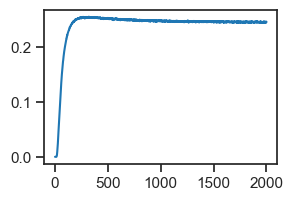

In [24]:
plot(results['r2'])
plt.show()

In [15]:
z = results['samples'][:, -1]
z.shape

(62, 256, 164, 164)

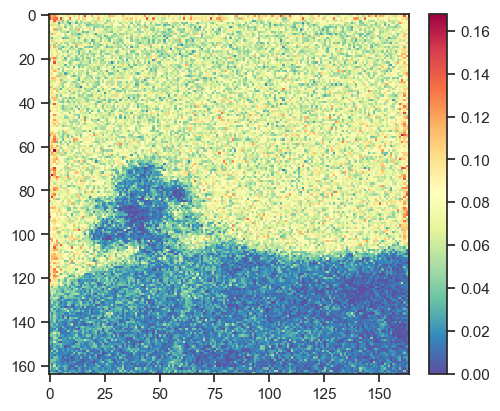

In [21]:
fig, ax = create_figure(1, 1, (5, 4))
im = ax.imshow(tonp(z[img_i].mean(0)), cmap='Spectral_r')
plt.colorbar(im, ax=ax)
plt.show()

In [25]:
results['recon'].shape

(62, 11, 1, 500, 500)

In [26]:
img_i

58

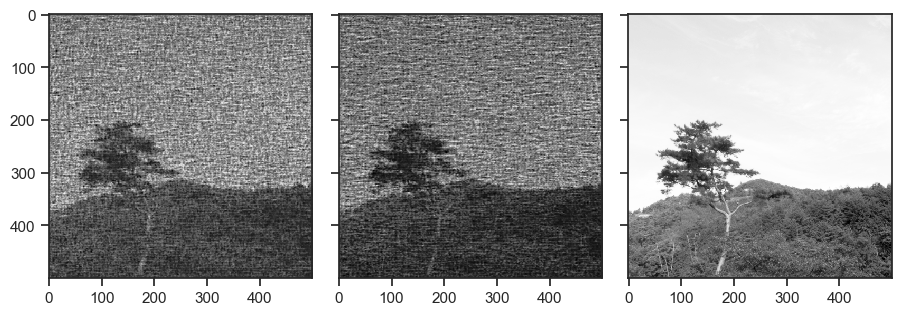

In [35]:
fig, axes = create_figure(1, 3, (9, 3), 'all', 'all')

x2p = tonp(results['recon'][img_i, 1].squeeze())
axes[0].imshow(x2p, cmap='Greys_r')

x2p = tonp(results['recon'][img_i, -1].squeeze())
axes[1].imshow(x2p, cmap='Greys_r')

axes[-1].imshow(bw[img_i], cmap='Greys_r')
plt.show()

In [37]:
from utils.imgproc import do_process

In [67]:
x_wt, x_wt_cn, x_wt_cn_zs = do_process(tr.to(bw).unsqueeze(1), crop_size=0)
x_wt_cn_zs.shape

torch.Size([62, 1, 500, 500])

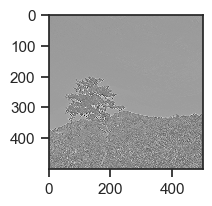

In [70]:
imshow(tonp(x_wt[img_i, 0]), cmap='Greys_r')
plt.show()

In [104]:
whitener = Whitening((500, 500), f_0=0.5, n=4, batched=True)

In [105]:
wht = whitener(tr.to(bw).unsqueeze(1))
wht.shape

torch.Size([62, 1, 500, 500])

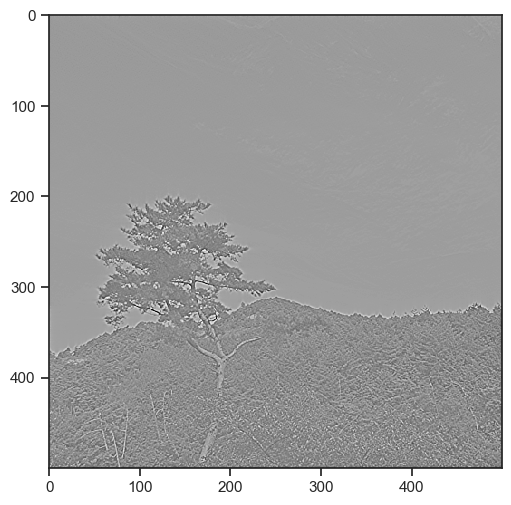

In [106]:
fig, ax = create_figure(1, 1, ( 5, 5))
ax.imshow(tonp(wht[img_i, 0]), cmap='Greys_r')
plt.show()

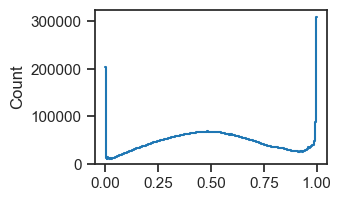

In [110]:
histplot(bw.ravel())
plt.show()

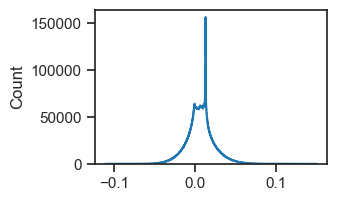

In [109]:
histplot(wht.ravel())
plt.show()

In [112]:
wht.shape

torch.Size([62, 1, 500, 500])

In [113]:
results = tr.xtract_ftr(
    data=tr.to(wht),
    t_total=1000,
    save_freq=100,
    return_recon=True,
)
list(results)

100%|██████████████████████████████████| 1/1 [02:35<00:00, 155.11s/it]


['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'times']

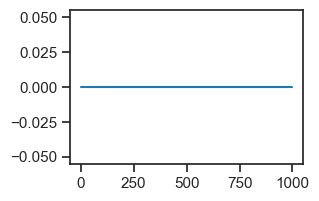

In [114]:
plot(results['r2'])
plt.show()

In [116]:
results['recon'].shape

(62, 11, 1, 500, 500)

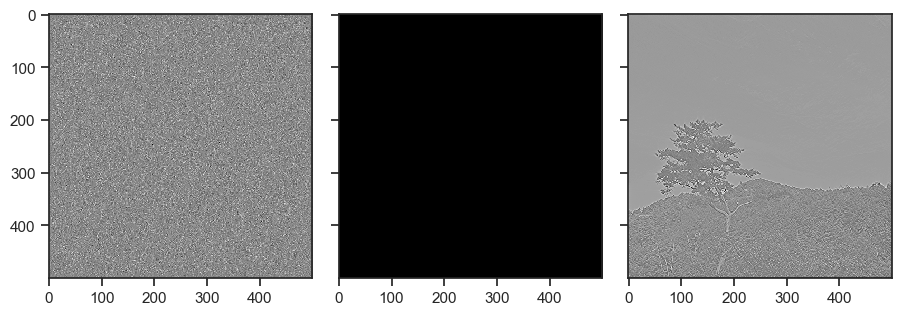

In [120]:
fig, axes = create_figure(1, 3, (9, 3), 'all', 'all')

x2p = tonp(results['recon'][img_i, 1].squeeze())
axes[0].imshow(x2p, cmap='Greys_r')

x2p = tonp(results['recon'][img_i, -1].squeeze())
axes[1].imshow(x2p, cmap='Greys_r')

axes[-1].imshow(tonp(wht[img_i, 0]), cmap='Greys_r')
plt.show()

In [14]:
x = tr.to(bw).unsqueeze(1)
x.shape

torch.Size([62, 1, 500, 500])

In [15]:
tr.model.layer.state

torch.Size([62, 1, 500, 500])
torch.Size([1, 1, 500, 500])

torch.Size([62, 1, 500, 500])
torch.Size([1, 1, 500, 500])

In [17]:
list(output)

['loss_kl', 'loss_recon', 'posterior']

In [ ]:
df = 

In [18]:
tr.model.layer.samples.shape

torch.Size([62, 256, 8, 8])

In [19]:
tr.model.layer.state[0].shape

torch.Size([62, 256, 8, 8])

## Analyze

### sort data

In [4]:
x_vld = tr.dl_vld.dataset.tensors[0]
var = torch.var(x_vld, dim=(1, 2, 3))
contrast_sort = torch.argsort(var)
x_vld = x_vld[contrast_sort]
tr.dl_vld.dataset.tensors = (x_vld, )

### plot

#### High contrast:

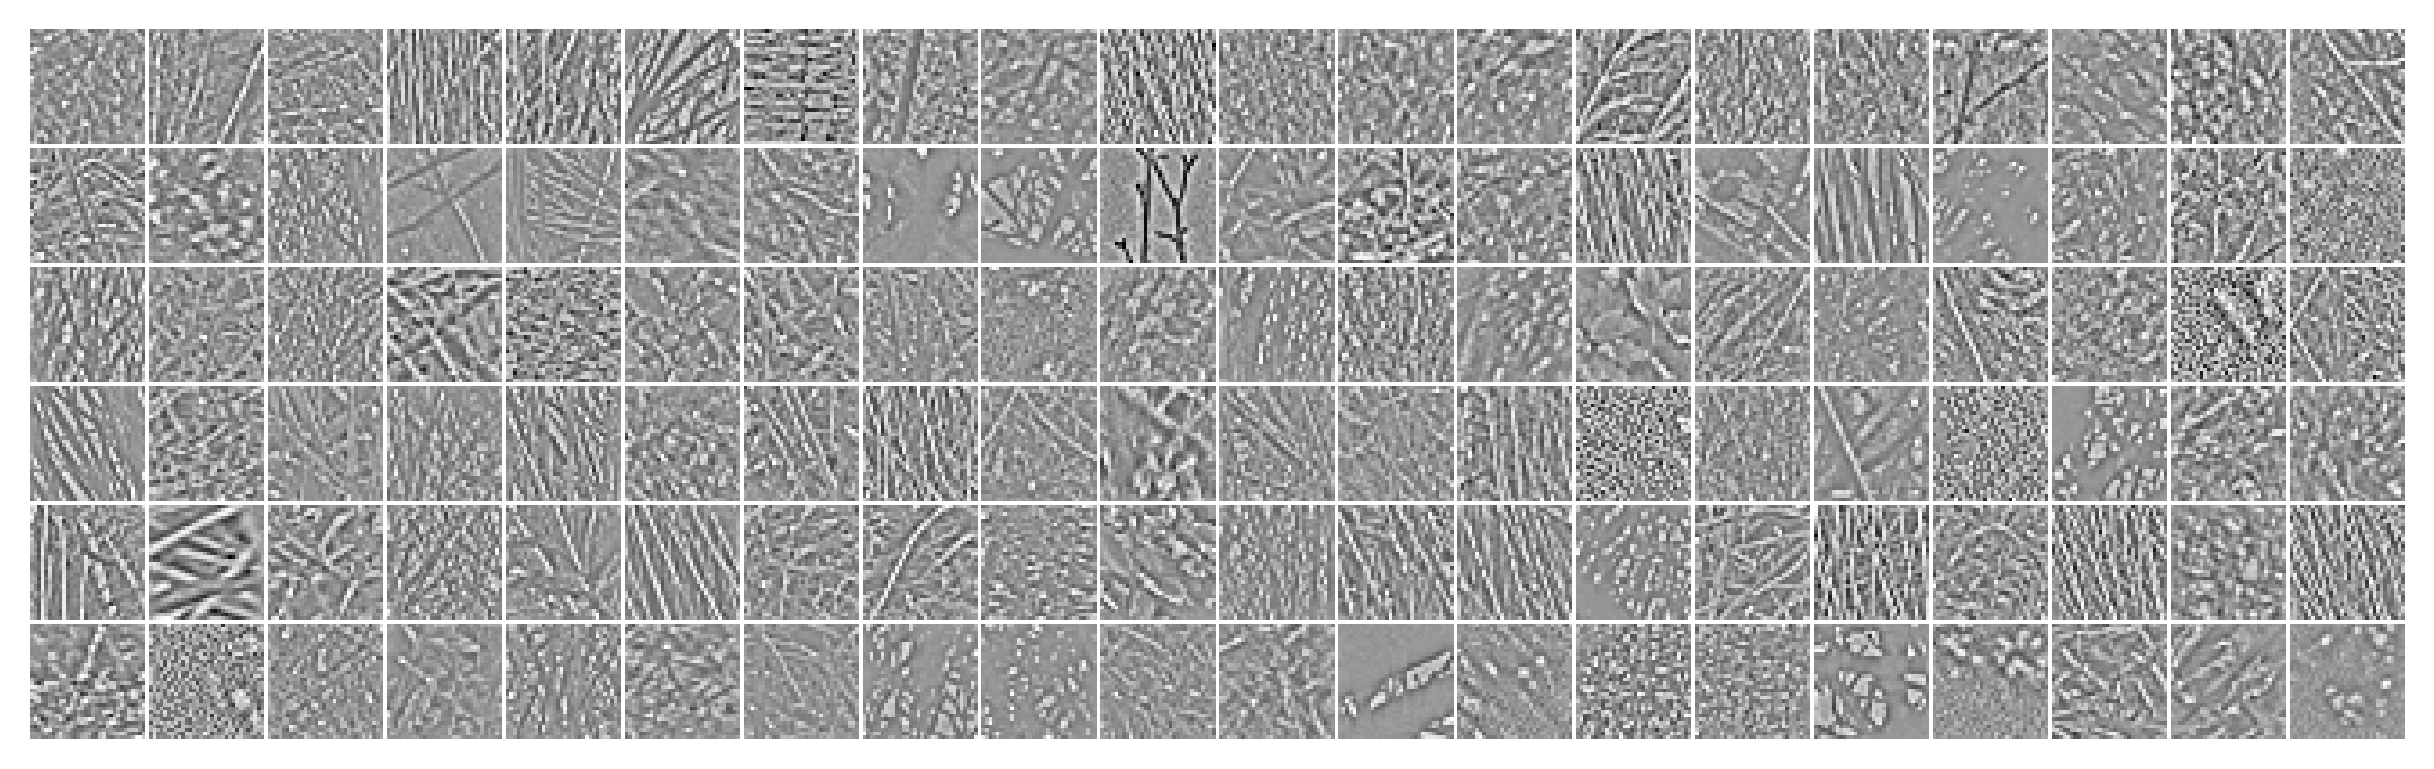

In [5]:
x2p = tonp(tr.dl_vld.dataset.tensors[0])[-120:]
plot_weights(x2p, nrows=6, dpi=300, method='abs-max');

#### Low contrast:

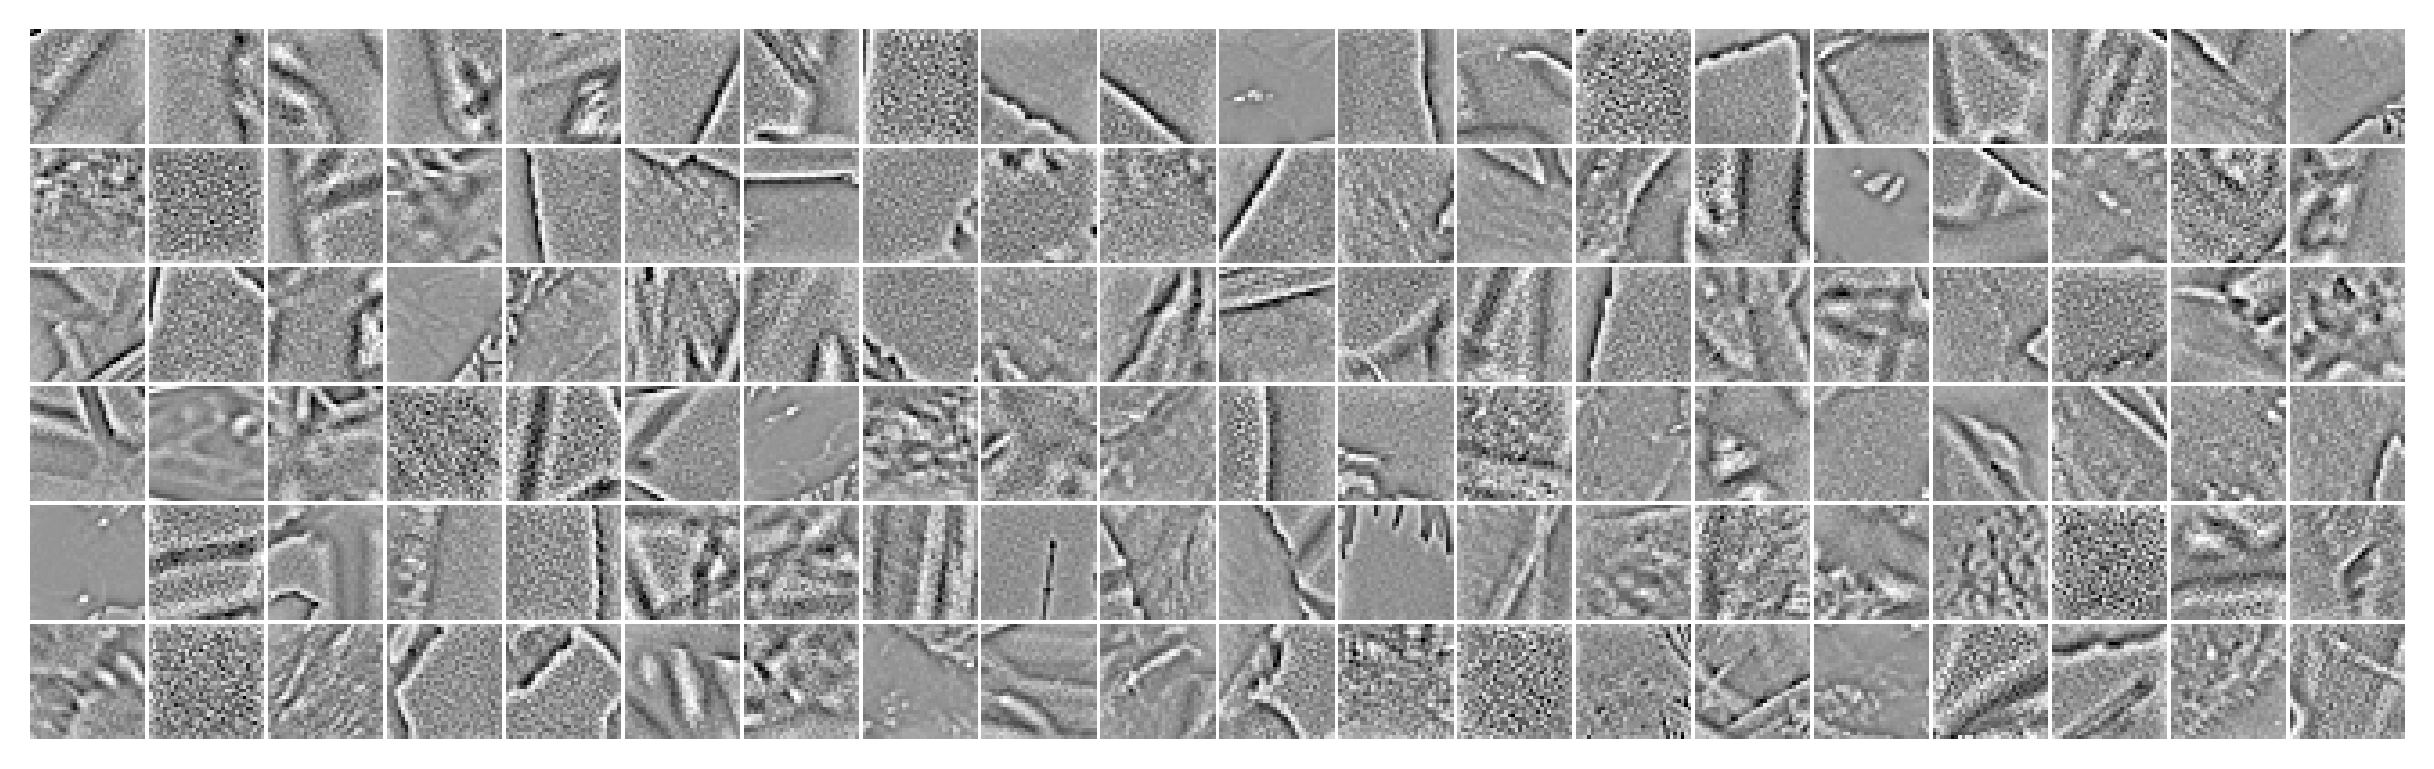

In [6]:
x2p = tonp(tr.dl_vld.dataset.tensors[0])[:120]
plot_weights(x2p, nrows=6, dpi=300, method='abs-max');

### Xtract ftrs

In [11]:
results = tr.analysis(t_total=111, n_data_batches=-1, avg_samples=False)
list(results)

100%|███████████████████████████████| 114/114 [00:48<00:00,  2.35it/s]


['kl',
 'r2',
 'mse',
 'loss',
 'du_norm',
 'lifetime',
 'population',
 '%-zeros',
 'state_final',
 'samples_final']

In [17]:
var.shape, results['r2'][:, -1].shape

(torch.Size([11303]), (11303,))

In [28]:
sp_stats.spearmanr(tonp(var), results['r2'][:, -1])

SignificanceResult(statistic=-0.010619488995188308, pvalue=0.25892990834104573)

In [22]:
r2_last = results['r2'][:, -1]
r2_last.shape

(11303,)

In [23]:
r2_last[:200].mean(), r2_last[-200:].mean()

(0.8733722, 0.90817565)

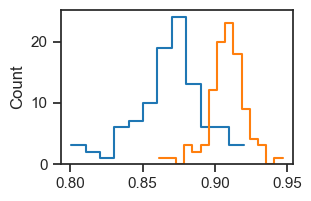

In [27]:
histplot(r2_last[:100], color='C0')
histplot(r2_last[-100:], color='C1')
plt.show()

In [30]:
tr.model.layer.samples.shape

torch.Size([3, 256, 8, 8])

In [37]:
z = tonp(tr.model.layer.samples[2])
z.shape

(256, 8, 8)

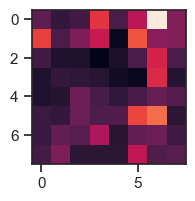

In [38]:
plt.imshow(z.mean(0))
plt.show()

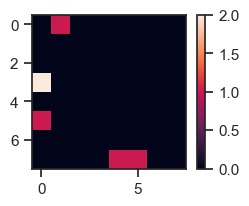

In [47]:
plt.imshow(z[14])
plt.colorbar()
plt.show()

In [50]:
portions = sparse_score(z.ravel(), cutoff=0.01)[-1]

/home/hadi/Dropbox/git/_TemporalSC/analysis/sparse.py:15: RuntimeWarning: divide by zero encountered in divide
  score /= (1 - 1 / m)
/home/hadi/Dropbox/git/_TemporalSC/analysis/sparse.py:15: RuntimeWarning: invalid value encountered in divide
  score /= (1 - 1 / m)


In [51]:
portions

{'0': 93.5, '1': 3.9, '2': 1.1, '3': 0.6, '4+': 0.9}

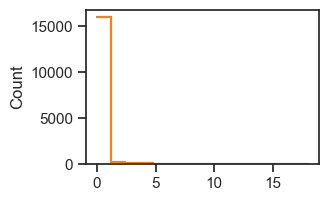

In [49]:
histplot(z.ravel())
plt.show()